# Decode Stim1 for a bad model

Choose one model and use SVM decoding to see if you can decode stim 1 identity during the delay period. 

I think there are a few ways of doing this, but we can try this first:
- Train SVM decoder using only correct trials (firing rates). I would maybe use average firing rates from the first half of the delay period here. We can play around with the time window here.
- Next test the decoder on correct trials (generate another set of correct trials). I would use the second half of the delay window.
- Test the decoder on incorrect trials (again use the second half of the delay window).

We would expect for the decoder to have good perf when tested on correct trials and poor perf on incorrect trials.

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *

2025-05-13 10:19:40.234653: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-13 10:19:40.242804: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-13 10:19:40.251743: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-13 10:19:40.254392: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-13 10:19:40.261698: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# import SVM
from sklearn import svm
from sklearn.metrics import confusion_matrix

## Load a bad model

In [3]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [4]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [5]:
# choose a model to visualize for now
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906'
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/acc_incorr_delay150.npy', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/neuraldata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/bhvdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/acc_corr_null_delay150.npy', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/timingdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/acc_corr_delay150.npy', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906/acc_incorr_null_delay150.npy']


In [6]:
# neural data
importlib.reload(ld)
_, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=False, load_spikes=False, load_rates=True)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)

In [7]:
rates_data.shape

(2055, 200, 1000)

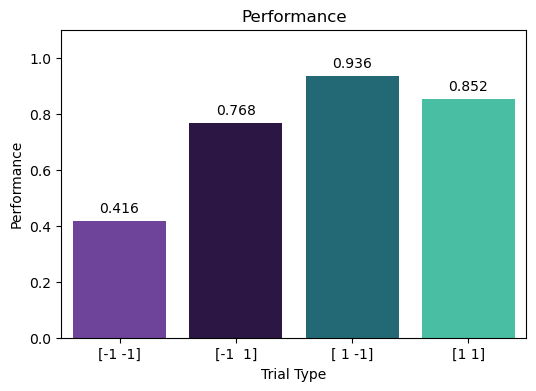

In [8]:
bhv.plot_trial_performance(model_name, condn_phrase, condn_num);

## Train SVM decoder using correct trials

Train SVM decoder using only correct trials (firing rates). I would maybe use average firing rates from the first half of the delay period here. We can play around with the time window here.

In [8]:
# split data into correct and incorrect

correct_idx = np.where(trial_perfs == 1)[0]
incorrect_idx = np.where(trial_perfs == 0)[0]

In [9]:
# get correct trials split of trial types

corr_labels = trial_labels[correct_idx] # get labels for correct trials
corr_types, corr_idxs = np.unique(corr_labels[:,0], return_inverse=True) # only for stim1, check balance
for i in range(len(corr_types)):
    print(f'Correct {corr_types[i]}: {np.sum(corr_idxs == i)}')

Correct -1: 296
Correct 1: 447


In [13]:
# first get balanced number of correct +1 and -1 via random sampling

n_corr = np.sum(corr_idxs == 0)
n_corr_pos = np.sum(corr_labels[:,0] == 1)
n_corr_neg = np.sum(corr_labels[:,0] == -1)
print(f'Number of correct trials: {n_corr}')
print(f'Number of correct +1 trials: {n_corr_pos}')
print(f'Number of correct -1 trials: {n_corr_neg}')

# get random sample of correct trials
n_corr_sample = int(np.min([n_corr_pos, n_corr_neg]))
print(f'Number of correct trials to sample: {n_corr_sample}')
corr_sample_pos = np.random.choice(np.where(corr_labels[:,0] == 1)[0], n_corr_sample, replace=False)
corr_sample_neg = np.random.choice(np.where(corr_labels[:,0] == -1)[0], n_corr_sample, replace=False)
corr_sample = np.concatenate((corr_sample_pos, corr_sample_neg))
print(f'Number of correct trials sampled: {len(corr_sample)}')

# get labels for sampled trials
corr_labels_sample = trial_labels[corr_sample,0]


Number of correct trials: 296
Number of correct +1 trials: 447
Number of correct -1 trials: 296
Number of correct trials to sample: 296
Number of correct trials sampled: 592


In [15]:
delay_times_half1 = np.arange(times_ms['stim1_off'], times_ms['stim1_off'] + np.round(times_ms['delay']/2)).astype(int)
delay_times_half2 = np.arange(times_ms['stim1_off'] + np.round(times_ms['delay']/2), times_ms['stim2_on']).astype(int)

In [31]:
print(train_data.shape)
print(test_data.shape)

(375, 200, 296)
(375, 200, 296)


In [41]:
# next do 50/50 split of correct trials
n_splits = 2
n_test = int(np.floor(len(corr_sample) / n_splits))
print(f'Number of test trials: {n_test}')
n_train = len(corr_sample) - n_test
print(f'Number of train trials: {n_train}')


test_idx = np.random.choice(corr_sample, n_test, replace=False)
train_idx = np.setdiff1d(corr_sample, test_idx)

# get labels for test and train trials
train_labels = trial_labels[train_idx,0]
test_labels = trial_labels[test_idx,0]

# get data for test and train trials  
train_data = np.mean(rates_data[delay_times_half1,:,:], axis=0) # train on first half delay of one set 
train_data = train_data[:, train_idx].T # train on first half delay of one set
test_data = np.mean(rates_data[delay_times_half2,:,:], axis=0) # test on second half delay of other set 
test_data_corr = test_data[:, test_idx].T # test on second half delay of other set

# fit SVM to training data
clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(train_data, train_labels)

# predict on test data
pred_labels_corr2 = clf.predict(test_data_corr)

# calculate accuracy
acc_corr2 = np.mean(pred_labels_corr2 == test_labels)
print(f'Accuracy: {acc_corr2}')



Number of test trials: 296
Number of train trials: 296
Accuracy: 0.9831081081081081


In [42]:
test_data_incorr = test_data[:, incorrect_idx].T
print(len(incorrect_idx))

pred_labels_incorr2 = clf.predict(test_data_incorr)
# calculate accuracy
acc_incorr2 = np.mean(pred_labels_incorr2 == trial_labels[incorrect_idx,0])
print(f'Accuracy: {acc_incorr2}')

257
Accuracy: 0.9688715953307393


In [44]:
test_labels

array([-1, -1, -1, -1,  1,  1,  1, -1,  1, -1, -1,  1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  1,  1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1, -1,  1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1,  1, -1, -1,  1, -1, -1,  1, -1, -1, -1, -1,
        1,  1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1,
       -1,  1, -1, -1, -1, -1,  1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1,
        1,  1, -1,  1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,  1, -1,
       -1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1, -1,  1,  1, -1, -1,  1,
        1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,  1,  1, -1, -1, -1,
       -1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1, -1, -1,
        1, -1,  1, -1, -1, -1, -1,  1, -1,  1,  1, -1, -1,  1, -1, -1, -1,
        1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,
        1, -1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1,  1, -1,
        1, -1, -1,  1,  1

In [43]:
train_labels

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [ ]:
# now try multiple times

n_iter = 100
acc_corr = np.zeros(n_iter)
acc_incorr = np.zeros(n_iter)

n_corr = np.sum(corr_idxs == 0)
n_corr_pos = np.sum(corr_labels[:,0] == 1)
n_corr_neg = np.sum(corr_labels[:,0] == -1)

# get random sample of correct trials
n_corr_sample = int(np.min([n_corr_pos, n_corr_neg]))

delay_times_half1 = np.arange(times_ms['stim1_off'], times_ms['stim1_off'] + np.round(times_ms['delay']/2)).astype(int)
delay_times_half2 = np.arange(times_ms['stim1_off'] + np.round(times_ms['delay']/2), times_ms['stim2_on']).astype(int)

for i in range(n_iter):
    corr_sample_pos = np.random.choice(np.where(corr_labels[:,0] == 1)[0], n_corr_sample, replace=False)
    corr_sample_neg = np.random.choice(np.where(corr_labels[:,0] == -1)[0], n_corr_sample, replace=False)
    corr_sample = np.concatenate((corr_sample_pos, corr_sample_neg))
    # get labels for sampled trials
    corr_labels_sample = trial_labels[corr_sample,0]

    n_splits = 2
    n_test = int(np.floor(len(corr_sample) / n_splits))
    n_train = len(corr_sample) - n_test

    n_cv = 5
    for j in range(n_cv):
        test_idx = np.random.choice(corr_sample, n_test, replace=False)
        train_idx = np.setdiff1d(corr_sample, test_idx)

        # get labels for test and train trials
        train_labels = trial_labels[train_idx,0]
        test_labels = trial_labels[test_idx,0]

        # get data for test and train trials  
        train_data = np.mean(rates_data[delay_times_half1,:,:], axis=0) # train on first half delay of one set 
        train_data = train_data[:, train_idx].T # train on first half delay of one set
        test_data = np.mean(rates_data[delay_times_half2,:,:], axis=0) # test on second half delay of other set 
        test_data_corr = test_data[:, test_idx].T # test on second half delay of other set

        # fit SVM to training data
        clf = svm.SVC(kernel='linear', C=1.0)
        clf.fit(train_data, train_labels)

        # predict on test data, from correct
        pred_labels_corr2 = clf.predict(test_data_corr)
        acc_corr[i] += np.mean(pred_labels_corr2 == test_labels)

        # predict on test data, from incorrect
        test_data_incorr = test_data[:, incorrect_idx].T
        pred_labels_incorr2 = clf.predict(test_data_incorr)
        acc_incorr[i] += np.mean(pred_labels_incorr2 == trial_labels[incorrect_idx,0])
    acc_corr[i] /= n_cv
    acc_incorr[i] /= n_cv

print(f'Mean Accuracy Corr: {np.mean(acc_corr)}')
print(f'Mean Accuracy Incorr: {np.mean(acc_incorr)}')
print(f'Std Corr: {np.std(acc_corr)}')
print(f'Std Incorr: {np.std(acc_incorr)}')


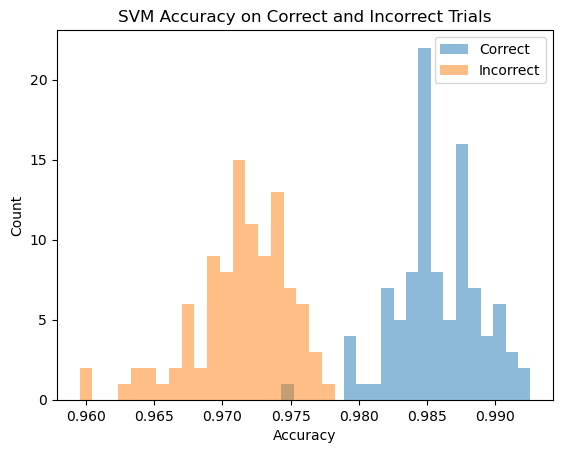

In [48]:
plt.hist(acc_corr, bins=20, alpha=0.5, label='Correct')
plt.hist(acc_incorr, bins=20, alpha=0.5, label='Incorrect')
plt.xlabel('Accuracy')
plt.ylabel('Count')
plt.title('SVM Accuracy on Correct and Incorrect Trials')
plt.legend()
plt.show()

In [49]:
# do a t-test
from scipy import stats
t_stat, p_val = stats.ttest_ind(acc_corr, acc_incorr)
print(f'T-statistic: {t_stat}')
print(f'P-value: {p_val}')

T-statistic: 30.381584698339964
P-value: 1.7870324508493873e-76


### modifications to decoder, w null distribution

In [10]:
# split data into correct and incorrect

correct_idx = np.where(trial_perfs == 1)[0]
incorrect_idx = np.where(trial_perfs == 0)[0]

In [11]:
# get correct trials split of trial types

corr_labels = trial_labels[correct_idx] # get labels for correct trials
corr_types, corr_idxs = np.unique(corr_labels[:,0], return_inverse=True) # only for stim1, check balance
for i in range(len(corr_types)):
    print(f'Correct {corr_types[i]}: {np.sum(corr_idxs == i)}')

Correct -1: 296
Correct 1: 447


In [14]:
# now try multiple times

n_iter = 100
n_cv = 100
acc_corr = np.zeros(n_iter)
acc_incorr = np.zeros(n_iter)
# save the null
acc_corr_null = np.zeros(n_iter)
acc_incorr_null = np.zeros(n_iter)

n_corr = np.sum(corr_idxs == 0)
n_corr_pos = np.sum(corr_labels[:,0] == 1)
n_corr_neg = np.sum(corr_labels[:,0] == -1)

# get random sample of correct trials
n_corr_sample = int(np.min([n_corr_pos, n_corr_neg]))

delay_times_half1 = np.arange(times_ms['stim1_off'], times_ms['stim1_off'] + np.round(times_ms['delay']/2)).astype(int)
delay_times_half2 = np.arange(times_ms['stim1_off'] + np.round(times_ms['delay']/2), times_ms['stim2_on']).astype(int)

for i in range(n_iter):
    corr_sample_pos = np.random.choice(np.where(corr_labels[:,0] == 1)[0], n_corr_sample, replace=True)
    corr_sample_neg = np.random.choice(np.where(corr_labels[:,0] == -1)[0], n_corr_sample, replace=True)
    corr_sample = np.concatenate((corr_sample_pos, corr_sample_neg))
    # get labels for sampled trials
    corr_labels_sample = trial_labels[corr_sample,0]

    n_splits = 2
    n_test = int(np.floor(len(corr_sample) / n_splits))
    n_train = len(corr_sample) - n_test

    for j in range(n_cv):
        test_idx = np.random.choice(corr_sample, n_test, replace=False)
        train_idx = np.setdiff1d(corr_sample, test_idx)

        # get labels for test and train trials
        train_labels = trial_labels[train_idx,0]
        test_labels = trial_labels[test_idx,0]

        # get data for test and train trials  
        train_data = np.mean(rates_data[delay_times_half1,:,:], axis=0) # train on first half delay of one set 
        train_data = train_data[:, train_idx].T # train on first half delay of one set
        test_data = np.mean(rates_data[delay_times_half2,:,:], axis=0) # test on second half delay of other set 
        test_data_corr = test_data[:, test_idx].T # test on second half delay of other set

        # fit SVM to training data
        clf = svm.SVC(kernel='linear', C=1.0)
        clf.fit(train_data, train_labels)
        clf_null = svm.SVC(kernel='linear', C=1.0) # null w shuffled labels
        train_labels_null = np.random.permutation(train_labels) # shuffle labels
        clf_null.fit(train_data, train_labels_null)

        # predict on test data, from correct
        pred_labels_corr2 = clf.predict(test_data_corr)
        pred_labels_corr2_null = clf_null.predict(test_data_corr)
        acc_corr[i] += np.mean(pred_labels_corr2 == test_labels)
        acc_corr_null[i] += np.mean(pred_labels_corr2_null == test_labels)
 
        # predict on test data, from incorrect
        test_data_incorr = test_data[:, incorrect_idx].T
        pred_labels_incorr2 = clf.predict(test_data_incorr)
        pred_labels_incorr2_null = clf_null.predict(test_data_incorr)
        acc_incorr[i] += np.mean(pred_labels_incorr2 == trial_labels[incorrect_idx,0])
        acc_incorr_null[i] += np.mean(pred_labels_incorr2_null == trial_labels[incorrect_idx,0])
    # average over cross-validation
    acc_corr[i] /= n_cv
    acc_incorr[i] /= n_cv
    acc_corr_null[i] /= n_cv
    acc_incorr_null[i] /= n_cv

print(f'Mean Accuracy Corr: {np.mean(acc_corr)}')
print(f'Mean Accuracy Incorr: {np.mean(acc_incorr)}')
print(f'Std Corr: {np.std(acc_corr)}')
print(f'Std Incorr: {np.std(acc_incorr)}')


Mean Accuracy Corr: 0.9829827702702703
Mean Accuracy Incorr: 0.9676225680933841
Std Corr: 0.005515587958896464
Std Incorr: 0.004801999424600077


In [16]:
# temp save these acc_corr, acc_incorr, acc_corr_null, acc_incorr_null
# save the data
np.save(os.path.join(model_dir, f'acc_corr_{condn_phrase}{condn_num}.npy'), acc_corr)
np.save(os.path.join(model_dir, f'acc_incorr_{condn_phrase}{condn_num}.npy'), acc_incorr)
np.save(os.path.join(model_dir, f'acc_corr_null_{condn_phrase}{condn_num}.npy'), acc_corr_null)
np.save(os.path.join(model_dir, f'acc_incorr_null_{condn_phrase}{condn_num}.npy'), acc_incorr_null)

In [7]:
# load the data
acc_corr = np.load(os.path.join(model_dir, f'acc_corr_{condn_phrase}{condn_num}.npy'))
acc_incorr = np.load(os.path.join(model_dir, f'acc_incorr_{condn_phrase}{condn_num}.npy'))
acc_corr_null = np.load(os.path.join(model_dir, f'acc_corr_null_{condn_phrase}{condn_num}.npy'))
acc_incorr_null = np.load(os.path.join(model_dir, f'acc_incorr_null_{condn_phrase}{condn_num}.npy'))
print(f'Mean Accuracy Corr: {np.mean(acc_corr)}')
print(f'Mean Accuracy Corr Null: {np.mean(acc_corr_null)}')
print(f'Mean Accuracy Incorr: {np.mean(acc_incorr)}')
print(f'Mean Accuracy Incorr Null: {np.mean(acc_incorr_null)}')

Mean Accuracy Corr: 0.9829827702702703
Mean Accuracy Corr Null: 0.5689979729729729
Mean Accuracy Incorr: 0.9676225680933841
Mean Accuracy Incorr Null: 0.5877303501945526


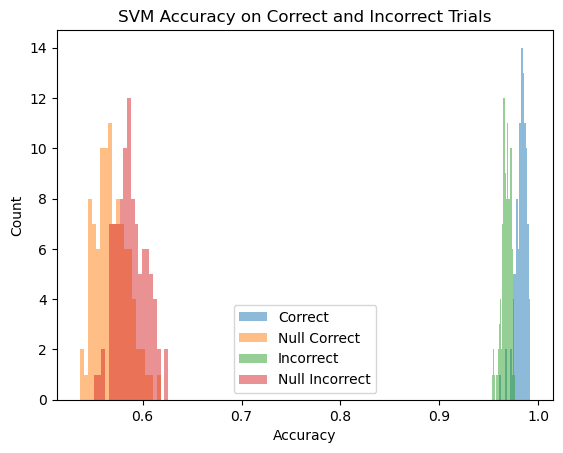

In [8]:
plt.hist(acc_corr, bins=20, alpha=0.5, label='Correct')
plt.hist(acc_corr_null, bins=20, alpha=0.5, label='Null Correct')
plt.hist(acc_incorr, bins=20, alpha=0.5, label='Incorrect')
plt.hist(acc_incorr_null, bins=20, alpha=0.5, label='Null Incorrect')
plt.xlabel('Accuracy')
plt.ylabel('Count')
plt.title('SVM Accuracy on Correct and Incorrect Trials')
plt.legend()
plt.show()

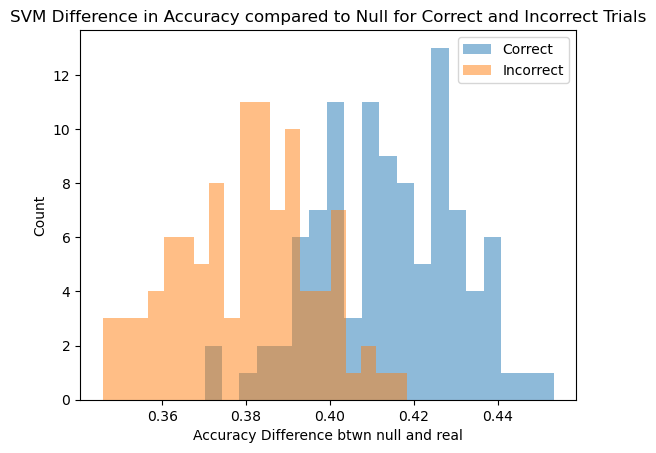

In [9]:
# plot difference between real and null

plt.hist(acc_corr - acc_corr_null, bins=20, alpha=0.5, label='Correct')
plt.hist(acc_incorr - acc_incorr_null, bins=20, alpha=0.5, label='Incorrect')
plt.xlabel('Accuracy Difference btwn null and real')
plt.ylabel('Count')
plt.title('SVM Difference in Accuracy compared to Null for Correct and Incorrect Trials')
plt.legend()
plt.show()